In [1]:
import qiskit
import qc_grader
print(f"Qiskit version: {qiskit.__version__}")
print(f"Grader version: {qc_grader.__version__}")


Qiskit version: 2.1.0
Grader version: 0.22.9


In [2]:
# Check that the account has been saved properly
from qiskit_ibm_runtime import QiskitRuntimeService


service = QiskitRuntimeService(name="qgss-2025")
service.saved_accounts()


{'default-ibm-cloud': {'channel': 'ibm_cloud',
  'url': 'https://cloud.ibm.com',
  'token': '202siqLmXAxw55XfOfseuslIZQoR9S92aSnONjEhNbca',
  'verify': True,
  'private_endpoint': False},
 'qgss-2025': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'mwlOvQ1IfMMT3cgwaqh2nnyza7iaLQDVf3tcllb9cDbv',
  'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/6d204dcfffad466b8ae3587b57906c92:941a73da-dc04-4764-a1a8-af51057930ee::',
  'verify': True,
  'private_endpoint': False}}

In [3]:
# Essential libraries
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import io

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.visualization import plot_histogram, plot_distribution
from qiskit_ibm_runtime import Options, Session, SamplerV2 as Sampler
from qiskit.result import marginal_distribution

from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

from qc_grader.challenges.qgss_2025 import (
    grade_lab1_ex1_1, 
    grade_lab1_ex1_2, 
    grade_lab1_ex1_3, 
    grade_lab1_ex1_4, 
    grade_lab1_ex2, 
    grade_lab1_ex3,
    grade_lab1_ex4,
    grade_lab1_ex5,
    grade_lab1_ex6
)

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit = QuantumCircuit(qr, cr)
# your code here
double_slit.h(qr[0])  # Apply Hadamard gate to create superposition



# end of your code
double_slit.draw('mpl')
grade_lab1_ex1_1(double_slit)


Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [5]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# Quantum and classical registers
qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit = QuantumCircuit(qr, cr)

# Step 1: Particle passes through double slit - create superposition
double_slit.h(qr[0])

# Step 2: Particle reaches center of screen - recombine paths (no phase difference)
double_slit.h(qr[0])

# Step 3: Measure the qubit to see the interference result
double_slit.measure(qr[0], cr[0])

# Draw the circuit
double_slit.draw('mpl')
grade_lab1_ex1_2(double_slit)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [6]:
import math
qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit_with_difference = QuantumCircuit(qr, cr)
double_slit_with_difference.h(0)

#your code here
double_slit_with_difference.p(math.pi/2, 0)  # Step 2: Apply phase difference of π (180°) to |1>
#end of your code

double_slit_with_difference.h(0)
double_slit_with_difference.measure(qr, cr)
double_slit_with_difference.draw('mpl')

grade_lab1_ex1_3(double_slit_with_difference)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [7]:
φ = Parameter('φ')

qr = QuantumRegister(1, name='q')
cr = ClassicalRegister(1, name='c_screen')

double_slit_fringe = QuantumCircuit(qr, cr)

#your code here

double_slit_fringe.h(0)  # Step 1: Particle passes through double slit - create superposition
double_slit_fringe.p(φ, 0)  # Step 2: Apply phase difference φ to |1>
double_slit_fringe.h(0)  # Step 3: Particle reaches center of screen - recombine paths
double_slit_fringe.measure(qr, cr)  # Step 4: Measure the qubit to see the interference result
#end of your code

double_slit_fringe.draw('mpl')
grade_lab1_ex1_4(double_slit_fringe)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [8]:
def schrodingers_cat_experiment_theta(theta):
    
    qc = QuantumCircuit(1)

    #your code start here
   
    qc.rx(theta, 0)  # Apply phase shift θ to the |1> state
  


    
    #end of your code

    qc.measure_all()
    
    backend = AerSimulator()
    pm = generate_preset_pass_manager( backend = backend, optimization_level=3)
    qc_isa = pm.run(qc)

    # Circuit compile and run, shot = 1 
    sampler = Sampler(mode=backend)
    counts = sampler.run([qc_isa], shots = 1).result()[0].data.meas.get_counts()

    measured_state = list(counts.keys())[0] if counts else '0'  # bring measured result

    if measured_state == '0':
        cat_happy = True
    else:
        cat_happy = False

    return cat_happy, qc

grade_lab1_ex2(schrodingers_cat_experiment_theta)


Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [9]:
qr = QuantumRegister(1, name='q')
cr1 = ClassicalRegister(1, name='c_detector')
cr2 = ClassicalRegister(1, name='c_screen')
double_slit_with_detector = QuantumCircuit(qr, cr1, cr2)

φ = Parameter('φ')

#your code here
double_slit_with_detector.h(qr)             # create superposition

double_slit_with_detector.measure(qr, cr1)  # which-path measurement (collapses the state)

double_slit_with_detector.p(φ, qr)         # apply phase shift

double_slit_with_detector.h(qr)             # recombine paths

double_slit_with_detector.measure(qr, cr2)   # final measurement on screen

#end of your code

double_slit_with_detector.draw('mpl')
grade_lab1_ex3(double_slit_with_detector)

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [10]:
from qiskit import QuantumCircuit
from math import pi

def create_chsh_circuit(x, y):
    """Builds Qiskit circuit for Alice & Bob's quantum strategy."""
    qc = QuantumCircuit(2, 2, name=f'CHSH_{x}{y}') # 2 qubits, 2 classical bits

    # ---- TODO : Task 1 ---
    # Create Bell state |Φ+> = (|00> + |11>)/sqrt(2)
    qc.h(0)          # Hadamard on Alice's qubit
    qc.cx(0, 1)      # CNOT from Alice to Bob
    # --- End of TODO ---
    
    qc.barrier()
    
    # Step 2a: Alice's measurement basis (X if x=1, Z if x=0)
    if x == 1:
        qc.h(0) # H for X-basis measurement
    
    ##  --- TODO: Task 2 ----
    # Step 2b: Bob's measurement basis
    if y == 0:
        qc.ry(-pi/4, 1)

    elif y == 1:
        qc.ry(pi/4, 1)
    
    # --- End of TODO ---
    
    qc.barrier()
    
    # Step 3: Measure
    qc.measure([0, 1], [0, 1]) # q0 to c0 (Alice), q1 to c1 (Bob) -> 'ba' format

    return qc
grade_lab1_ex4(create_chsh_circuit)



Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


Quantum circuit for inputs x=1, y=1 (Check your Exercises 1 & 2 implementation):


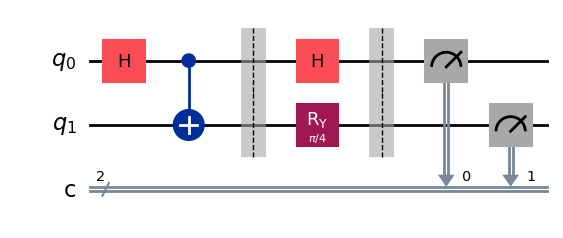

In [11]:
circuits = []
input_pairs = []
for x_in in [0, 1]:
    for y_in in [0, 1]:
        input_pairs.append((x_in, y_in))
        circuits.append(create_chsh_circuit(x_in, y_in))

print("Quantum circuit for inputs x=1, y=1 (Check your Exercises 1 & 2 implementation):")
if len(circuits) == 4:
    display(circuits[3].draw('mpl')) # (x,y) = (1,1)
else:
    print("Circuits not generated. Run previous cell after completing Exercises 1 & 2.")

In [16]:
# AerSimulator (if not already defined)
# backend = AerSimulator()
# Pass manager (if not already defined)
# pm = generate_preset_pass_manager(backend=backend, optimization_level=1)

SHOTS = 1024

print("Preparing circuits for the simulator...")
isa_qc_chsh = pm.run(circuits)

sampler_chsh = Sampler(mode=backend) # SamplerV2
job_chsh = sampler_chsh.run(isa_qc_chsh, shots=SHOTS)
results_chsh = job_chsh.result()

# SamplerV2: results_chsh[i].data.c.get_counts() where 'c' is the default name of classical register
counts_list = [results_chsh[i].data.c.get_counts() for i in range(len(circuits))]

print("\n--- Simulation Results (Counts) ---")
for i, (x, y) in enumerate(input_pairs):
    print(f"Inputs (x={x}, y={y}):")
    sorted_counts = dict(sorted(counts_list[i].items()))
    print(f"  Outcomes (ba): {sorted_counts}")

print("\nPlotting results...")
display(plot_histogram(counts_list,
                       legend=[f'(x={x}, y={y})' for x, y in input_pairs],
                       title='CHSH Game Outcomes (ba format)'))

Preparing circuits for the simulator...


NameError: name 'pm' is not defined

In [17]:
win_probabilities = {}
print("--- Calculating Win Probabilities ---")

for i, (x, y) in enumerate(input_pairs):
    counts = counts_list[i]

    # Task 1: Determine target a XOR b for winning
    target_xor_result = x & y  # x * y

    wins_for_this_case = 0

    # Task 2: Count shots satisfying the win condition
    for bitstring, count in counts.items():
        a = int(bitstring[1])  # 'ba' format, so a is second bit
        b = int(bitstring[0])  # b is first bit
        if (a ^ b) == target_xor_result:
            wins_for_this_case += count

    prob = wins_for_this_case / SHOTS if SHOTS > 0 else 0
    win_probabilities[(x, y)] = prob
    print(f"Inputs (x={x}, y={y}): Target (a XOR b) = {target_xor_result}. Win Probability = {prob:.4f}")

avg_win_prob = sum(win_probabilities.values()) / 4.0
P_win_quantum_theory = np.cos(np.pi / 8)**2  # ~0.8536
P_win_classical_limit = 0.75

print("\n--- Overall Performance ---")
print(f"Experimental Average Win Probability: {avg_win_prob:.4f}")
print(f"Theoretical Quantum Win Probability: {P_win_quantum_theory:.4f}")
print(f"Classical Limit Win Probability:     {P_win_classical_limit:.4f}")

if avg_win_prob > P_win_classical_limit + 0.01:
    print(f"\nSuccess! Your result ({avg_win_prob:.4f}) clearly beats the classical 75% limit!")
    print(f"It's likely close to the theoretical quantum prediction of {P_win_quantum_theory:.4f}.")
elif avg_win_prob > P_win_classical_limit - 0.02:
     print(f"\nClose, but no cigar? Your result ({avg_win_prob:.4f}) is around the classical limit ({P_win_classical_limit:.4f}).")
     print("Check your solutions for Exercises 1-4 carefully, especially the win counting logic in Ex 4.")
else:
    print(f"\nHmm, the result ({avg_win_prob:.4f}) is unexpectedly low, even below the classical limit.")
    print("There might be an error in Exercises 1-4. Please review your circuit and analysis code.")


grade_lab1_ex5(counts_list, avg_win_prob)




--- Calculating Win Probabilities ---


NameError: name 'counts_list' is not defined

In [18]:
from qc_grader.grader.grade import check_lab_completion_status
check_lab_completion_status("qgss_2025")

Lab 0: 2/2 exercises completed (100%)
    ✅ 1300 participants have completed this lab
Lab 1: 9/9 exercises completed (100%)
    ✅ 330 participants have completed this lab
Lab 2: 0/7 exercises completed (0%)
    ✅ 1 participants have completed this lab
Lab 3: 0/5 exercises completed (0%)
    ✅ 0 participants have completed this lab
Lab 4: 0/6 exercises completed (0%)
    ✅ 0 participants have completed this lab


Full Teleportation Circuit (Check your Exercises 1, 2, 3):


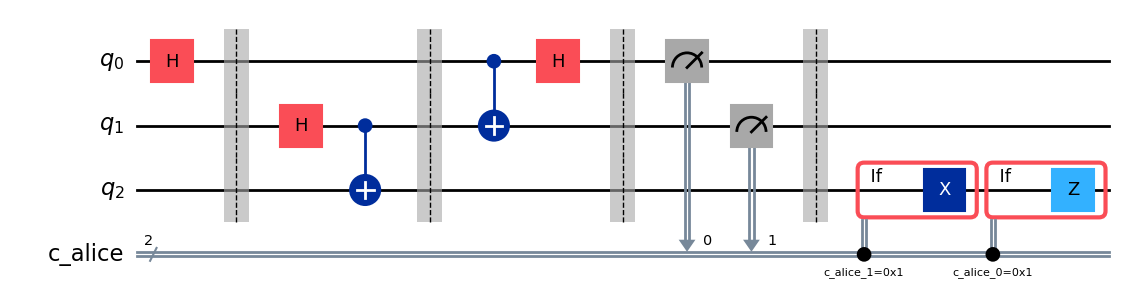

Submitting your answer. Please wait...
Congratulations! 🎉 Your answer is correct.


In [14]:
# Define quantum and classical registers
qr_tele = QuantumRegister(3, name='q')
cr_alice_tele = ClassicalRegister(2, name='c_alice') # For Alice's measurements

# For verification with statevector, we don't measure Bob's final qubit in this circuit.
# If we were to run on hardware and verify by counts, we'd add a classical bit for Bob.
teleport_qc = QuantumCircuit(qr_tele, cr_alice_tele, name='Teleportation')

# Prepare Alice's message state |ψ> = |+> on q0
teleport_qc.h(qr_tele[0])
teleport_qc.barrier()

# ---- TODO : Task 1 ---
# Step 1: Create Bell pair between q1 (Alice) and q2 (Bob)
teleport_qc.h(qr_tele[1])      # Apply Hadamard to q1
teleport_qc.cx(qr_tele[1], qr_tele[2])  # CNOT from q1 to q2



# --- End of TODO --
teleport_qc.barrier()

# ---- TODO : Task 2 ---
# Step 2: Alice's Bell Measurement (gates part)
teleport_qc.cx(qr_tele[0], qr_tele[1])  # CNOT from q0 (message) to q1 (Alice's half of Bell pair)
teleport_qc.h(qr_tele[0])               # Hadamard on q0



# --- End of TODO --
teleport_qc.barrier()

# Alice measures her qubits q0 and q1
teleport_qc.measure(qr_tele[0], cr_alice_tele[0]) # q0 -> c0
teleport_qc.measure(qr_tele[1], cr_alice_tele[1]) # q1 -> c1
teleport_qc.barrier()

# ---- TODO : Task 3 ---
# Step 3: Bob's Conditional Corrections on q2

with teleport_qc.if_test((cr_alice_tele[1], 1)):
    teleport_qc.x(2)

with teleport_qc.if_test((cr_alice_tele[0], 1)):
    teleport_qc.z(2)



# --- End of TODO --

print("Full Teleportation Circuit (Check your Exercises 1, 2, 3):")
display(teleport_qc.draw('mpl'))
grade_lab1_ex6(teleport_qc)